In [1]:
# ======================================================
# Fine KNN on Fruit Disease Dataset
# ======================================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_fscore_support
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from tqdm import tqdm

In [3]:
# ======================================================
# Paths
# ======================================================
TRAIN_DIR = "/content/drive/MyDrive/datasets/train"
TEST_DIR = "/content/drive/MyDrive/datasets/test"
IMAGE_SIZE = (128, 128)

In [4]:
# ======================================================
# Load Training Dataset
# ======================================================
X, y = [], []
print("Loading training dataset...")
for label in tqdm(os.listdir(TRAIN_DIR)):
    label_path = os.path.join(TRAIN_DIR, label)
    if not os.path.isdir(label_path):
        continue
    for img_name in os.listdir(label_path):
        img_path = os.path.join(label_path, img_name)
        try:
            img = load_img(img_path, target_size=IMAGE_SIZE)
            img_array = img_to_array(img)
            X.append(img_array)
            y.append(label)
        except:
            pass

X = np.array(X, dtype="float32") / 255.0
y = np.array(y)
print(f"✅ Loaded {len(X)} images from {len(np.unique(y))} classes.")

# ======================================================
# Train-Validation Split
# ======================================================
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


Loading training dataset...


100%|██████████| 21/21 [11:16<00:00, 32.24s/it]


✅ Loaded 6399 images from 21 classes.


In [5]:

# ======================================================
# Flatten for KNN input
# ======================================================
X_train_flat = X_train.reshape(len(X_train), -1)
X_val_flat = X_val.reshape(len(X_val), -1)

# Encode labels
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.transform(y_val)

# Standardize features
scaler = StandardScaler()
X_train_flat = scaler.fit_transform(X_train_flat)
X_val_flat = scaler.transform(X_val_flat)

In [6]:
# ======================================================
# Train Fine KNN (k=3, weighted)
# ======================================================
print("\n🚀 Training Fine KNN (k=3)...")
fine_knn = KNeighborsClassifier(n_neighbors=3, weights='distance', metric='euclidean')
fine_knn.fit(X_train_flat, y_train_enc)



🚀 Training Fine KNN (k=3)...


KNeighborsClassifier(metric='euclidean', n_neighbors=3, weights='distance')

In [7]:

# ======================================================
# Evaluate on Validation
# ======================================================
y_pred_val = fine_knn.predict(X_val_flat)
print("\n✅ Validation Results:")
print("Accuracy:", accuracy_score(y_val_enc, y_pred_val))
print("\nClassification Report:")
print(classification_report(y_val_enc, y_pred_val, target_names=label_encoder.classes_))


✅ Validation Results:
Accuracy: 0.684375

Classification Report:
                                           precision    recall  f1-score   support

                     Grape__black_measles       0.87      0.51      0.64       198
                         Grape__black_rot       0.65      0.75      0.70       142
                           Grape__healthy       0.51      0.85      0.64        68
Grape__leaf_blight_(isariopsis_leaf_spot)       0.76      0.86      0.81       128
                          Lemon__diseased       0.40      0.20      0.27        10
                           Lemon__healthy       0.71      0.91      0.80        22
                    Pomegranate__diseased       0.94      0.87      0.90        38
                     Pomegranate__healthy       0.78      0.95      0.85        40
                       guava_Disease Free       0.50      0.83      0.62        18
                        guava_Phytopthora       0.00      0.00      0.00        16
                    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [8]:
# ======================================================
# Load Test Dataset
# ======================================================
X_test, y_test = [], []
print("\n📦 Loading test dataset...")
for label in tqdm(os.listdir(TEST_DIR)):
    label_path = os.path.join(TEST_DIR, label)
    if not os.path.isdir(label_path):
        continue
    for img_name in os.listdir(label_path):
        img_path = os.path.join(label_path, img_name)
        try:
            img = load_img(img_path, target_size=IMAGE_SIZE)
            img_array = img_to_array(img)
            X_test.append(img_array)
            y_test.append(label)
        except:
            pass

X_test = np.array(X_test, dtype="float32") / 255.0
y_test = np.array(y_test)

X_test_flat = X_test.reshape(len(X_test), -1)
X_test_flat = scaler.transform(X_test_flat)
y_test_enc = label_encoder.transform(y_test)


📦 Loading test dataset...


100%|██████████| 21/21 [06:34<00:00, 18.76s/it]


In [9]:
# ======================================================
# Predict on Test Data
# ======================================================
y_pred_test = fine_knn.predict(X_test_flat)

In [10]:


# ======================================================
# Evaluation Metrics
# ======================================================
acc = accuracy_score(y_test_enc, y_pred_test)
precision, recall, f1, _ = precision_recall_fscore_support(y_test_enc, y_pred_test, average='weighted')

print("\n🎯 Test Results (Fine KNN):")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_test, target_names=label_encoder.classes_))


🎯 Test Results (Fine KNN):
Accuracy: 0.6859
Precision: 0.6987
Recall: 0.6859
F1 Score: 0.6728

Classification Report:
                                           precision    recall  f1-score   support

                     Grape__black_measles       0.86      0.47      0.61       277
                         Grape__black_rot       0.63      0.73      0.68       200
                           Grape__healthy       0.51      0.89      0.65        94
Grape__leaf_blight_(isariopsis_leaf_spot)       0.72      0.89      0.80       178
                          Lemon__diseased       0.64      0.44      0.52        16
                           Lemon__healthy       0.71      0.78      0.75        32
                    Pomegranate__diseased       0.90      0.82      0.86        55
                     Pomegranate__healthy       0.76      0.98      0.86        58
                       guava_Disease Free       0.77      0.92      0.84        26
                        guava_Phytopthora       0.

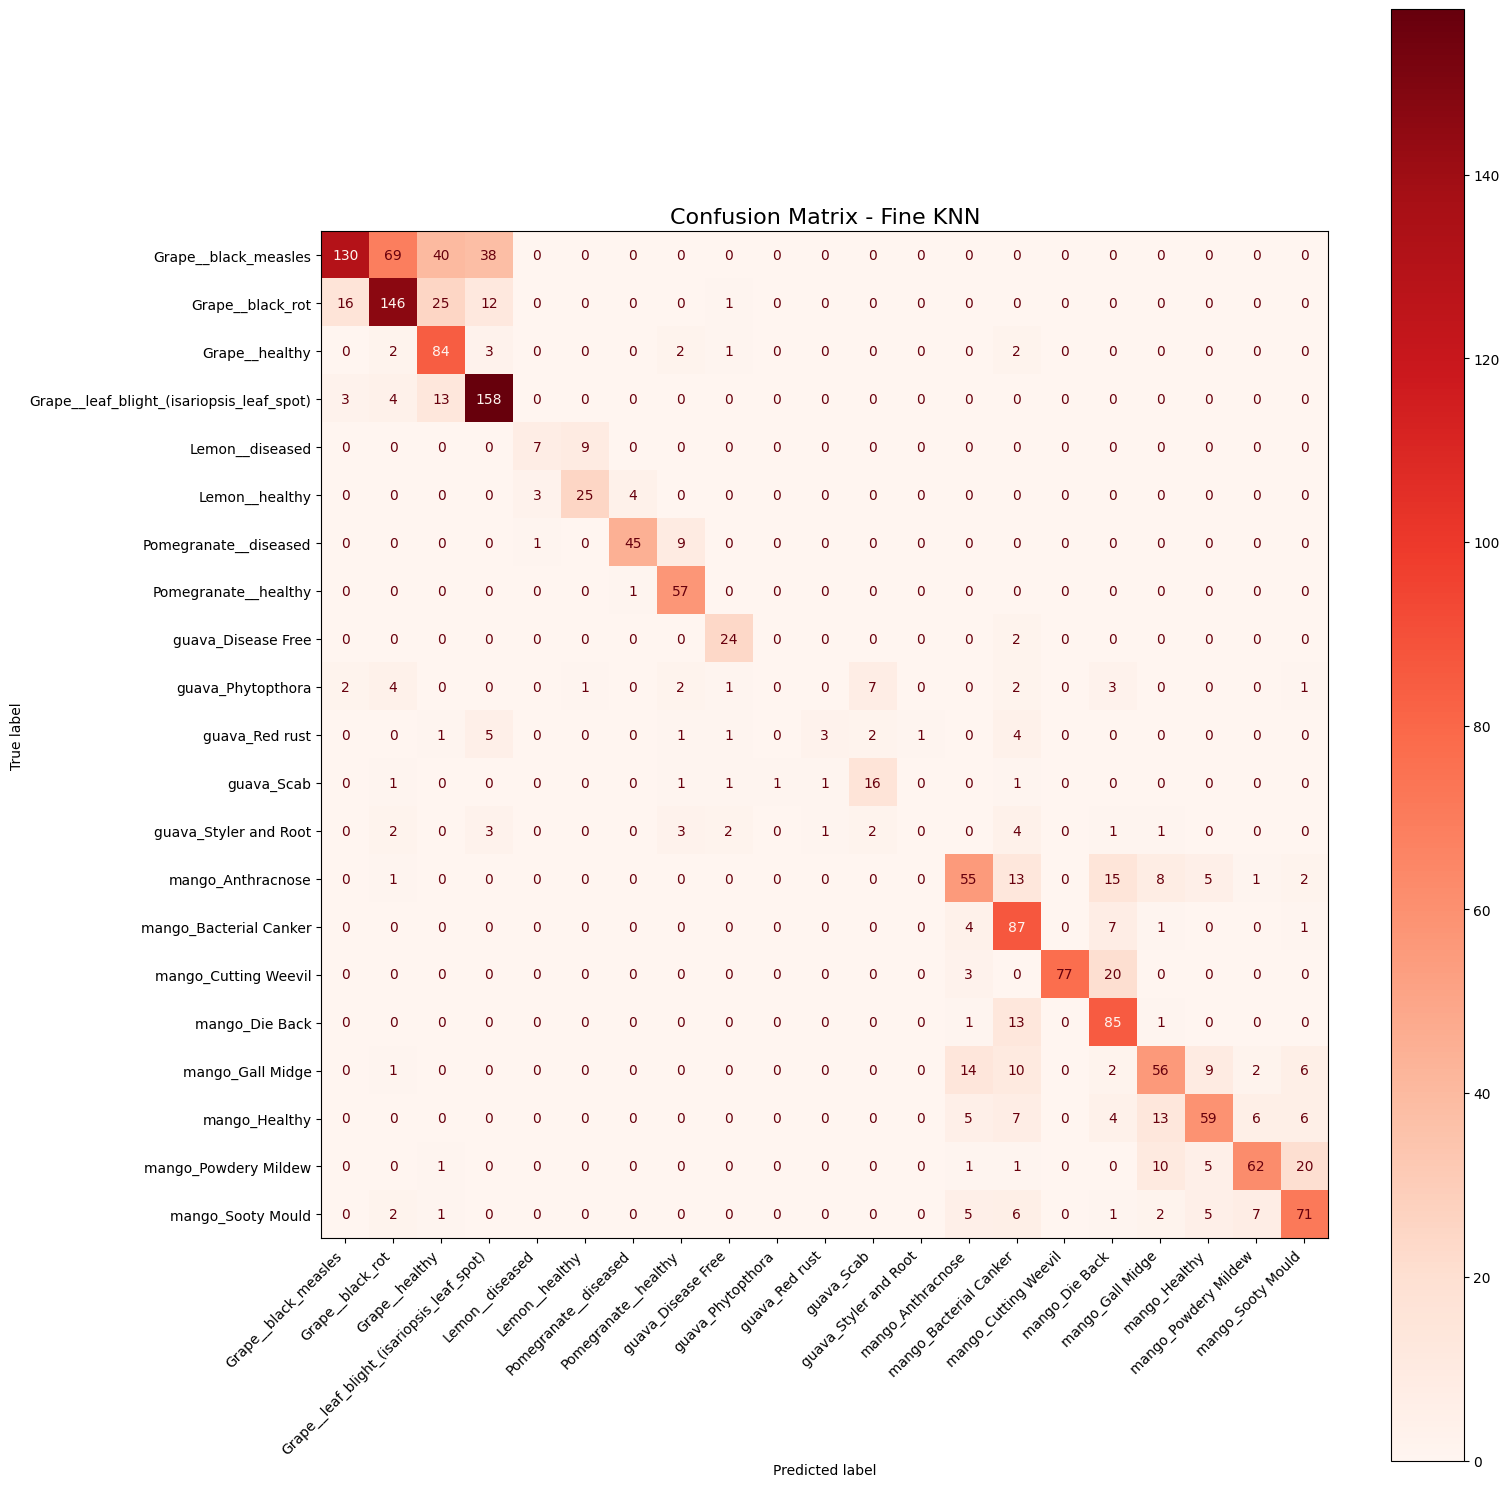

In [14]:
fig, ax = plt.subplots(figsize=(16, 16))  # Make it larger
disp.plot(cmap="Reds", ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix - Fine KNN", fontsize=16)
plt.xticks(fontsize=10, rotation=45, ha='right')  # Rotate & align labels
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

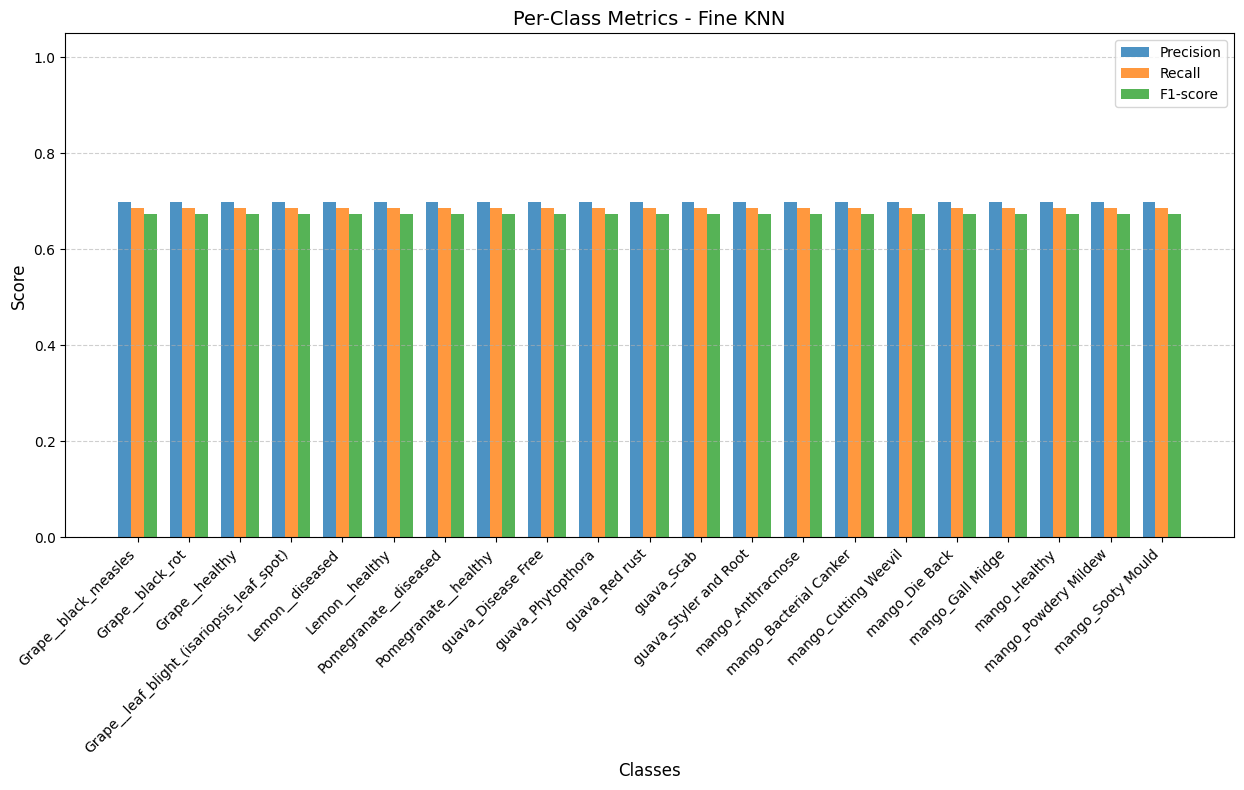

In [16]:
plt.figure(figsize=(max(10, len(label_encoder.classes_) * 0.6), 8))  # auto-scale width
x = np.arange(len(label_encoder.classes_))
bar_width = 0.25

plt.bar(x - bar_width, precision, width=bar_width, label='Precision', alpha=0.8)
plt.bar(x, recall, width=bar_width, label='Recall', alpha=0.8)
plt.bar(x + bar_width, f1, width=bar_width, label='F1-score', alpha=0.8)

plt.xticks(x, label_encoder.classes_, rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.title("Per-Class Metrics - Fine KNN", fontsize=14)
plt.xlabel("Classes", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.ylim(0, 1.05)
plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()